In [74]:
# pandas: data-analysis library providing the DataFrame — alias "pds"
import pandas as pds
# matplotlib.pyplot: plotting library — alias "plt"
import matplotlib.pyplot as plt

# Jupyter magic: render plots inside the notebook output
%matplotlib inline

In [75]:
# import urllib.request
# from pathlib import Path

# CSV_URL = "https://raw.githubusercontent.com/EdManDev/Python_code_ML/main/DSAT/sp500.csv"

# # sp500.csv lives in DSAT/ (one level above this notebook) — resolve it
# # relative to wherever the kernel actually runs
# hits = [d / "sp500.csv" for d in (Path.cwd(), *Path.cwd().parents) if (d / "sp500.csv").exists()]
# if not hits:  # kernel started above the project (e.g. repo root) — search below cwd
#     hits = sorted(Path.cwd().glob("*/sp500.csv"))
# if not hits:  # nothing on this machine (e.g. Google Colab at /content) — fetch from GitHub
#     urllib.request.urlretrieve(CSV_URL, "sp500.csv")
#     hits = [Path("sp500.csv")]

# load the CSV from the parent folder into a DataFrame (Date kept as a plain column)
database = pds.read_csv("../sp500.csv")
# display the DataFrame (last expression of the cell)
database

,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-01-02,2058.899902,2072.360107,2046.040039,2058.199951,2058.199951,2708700000
1,2015-01-05,2054.439941,2054.439941,2017.339966,2020.579956,2020.579956,3799120000
2,2015-01-06,2022.150024,2030.250000,1992.439941,2002.609985,2002.609985,4460110000
3,2015-01-07,2005.550049,2029.609985,2005.550049,2025.900024,2025.900024,3805480000
4,2015-01-08,2030.609985,2064.080078,2030.609985,2062.139893,2062.139893,3934010000
...,...,...,...,...,...,...,...
750,2017-12-22,2684.219971,2685.350098,2678.129883,2683.340088,2683.340088,2399830000
751,2017-12-26,2679.090088,2682.739990,2677.959961,2680.500000,2680.500000,1968780000
752,2017-12-27,2682.100098,2685.639893,2678.909912,2682.620117,2682.620117,2202080000
753,2017-12-28,2686.100098,2687.659912,2682.689941,2687.540039,2687.540039,2153330000


In [76]:
# reload with Date as a datetime index (enables .loc["2017"] slicing)
database = pds.read_csv("../sp500.csv", index_col="Date", parse_dates=True)
# display the DataFrame
database

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-01-02,2058.899902,2072.360107,2046.040039,2058.199951,2058.199951,2708700000
2015-01-05,2054.439941,2054.439941,2017.339966,2020.579956,2020.579956,3799120000
2015-01-06,2022.150024,2030.250000,1992.439941,2002.609985,2002.609985,4460110000
2015-01-07,2005.550049,2029.609985,2005.550049,2025.900024,2025.900024,3805480000
2015-01-08,2030.609985,2064.080078,2030.609985,2062.139893,2062.139893,3934010000
...,...,...,...,...,...,...
2017-12-22,2684.219971,2685.350098,2678.129883,2683.340088,2683.340088,2399830000
2017-12-26,2679.090088,2682.739990,2677.959961,2680.500000,2680.500000,1968780000
2017-12-27,2682.100098,2685.639893,2678.909912,2682.620117,2682.620117,2202080000


In [77]:
# daily returns: each value divided by the previous day's value, minus 1
pctdata = database.pct_change(1)
# display — the first row is NaN because it has no previous day
pctdata

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-05,-0.002166,-0.008647,-0.014027,-0.018278,-0.018278,0.402562
2015-01-06,-0.015717,-0.011774,-0.012343,-0.008893,-0.008893,0.173985
2015-01-07,-0.008209,-0.000315,0.006580,0.011630,0.011630,-0.146774
2015-01-08,0.012495,0.016984,0.012495,0.017888,0.017888,0.033775
...,...,...,...,...,...,...
2017-12-22,0.000447,-0.002707,-0.001592,-0.000458,-0.000458,-0.266867
2017-12-26,-0.001911,-0.000972,-0.000063,-0.001058,-0.001058,-0.179617
2017-12-27,0.001124,0.001081,0.000355,0.000791,0.000791,0.118500


In [78]:
# same daily returns, with the NaN first row removed
pctdata = database.pct_change(1).dropna()
# display the clean returns table
pctdata

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-01-05,-0.002166,-0.008647,-0.014027,-0.018278,-0.018278,0.402562
2015-01-06,-0.015717,-0.011774,-0.012343,-0.008893,-0.008893,0.173985
2015-01-07,-0.008209,-0.000315,0.006580,0.011630,0.011630,-0.146774
2015-01-08,0.012495,0.016984,0.012495,0.017888,0.017888,0.033775
2015-01-09,0.016172,0.000169,0.003802,-0.008404,-0.008404,-0.144857
...,...,...,...,...,...,...
2017-12-22,0.000447,-0.002707,-0.001592,-0.000458,-0.000458,-0.266867
2017-12-26,-0.001911,-0.000972,-0.000063,-0.001058,-0.001058,-0.179617
2017-12-27,0.001124,0.001081,0.000355,0.000791,0.000791,0.118500


In [79]:
# standard deviation / mean
# average daily return of each column
pctdata.mean()

Open         0.000380
High         0.000364
Low          0.000382
Close        0.000377
Adj Close    0.000377
Volume       0.014848
dtype: float64

In [80]:
# standard deviation of the daily returns = volatility of each column
pctdata.std()

Open         0.007156
High         0.005853
Low          0.007365
Close        0.007772
Adj Close    0.007772
Volume       0.187906
dtype: float64

In [81]:
# summary statistics table: count, mean, std, min, quartiles, max
pctdata.describe()

,Open,High,Low,Close,Adj Close,Volume
count,754.000000,754.000000,754.000000,754.000000,754.000000,754.000000
mean,0.000380,0.000364,0.000382,0.000377,0.000377,0.014848
std,0.007156,0.005853,0.007365,0.007772,0.007772,0.187906
min,-0.034395,-0.034395,-0.052707,-0.039414,-0.039414,-0.594769
25%,-0.002740,-0.002369,-0.002786,-0.002753,-0.002753,-0.074960
50%,0.000672,0.000165,0.000947,0.000291,0.000291,-0.002164
75%,0.003833,0.003529,0.004137,0.004083,0.004083,0.079478
max,0.037389,0.023936,0.037389,0.039034,0.039034,1.914449


<Axes: xlabel='Date'>

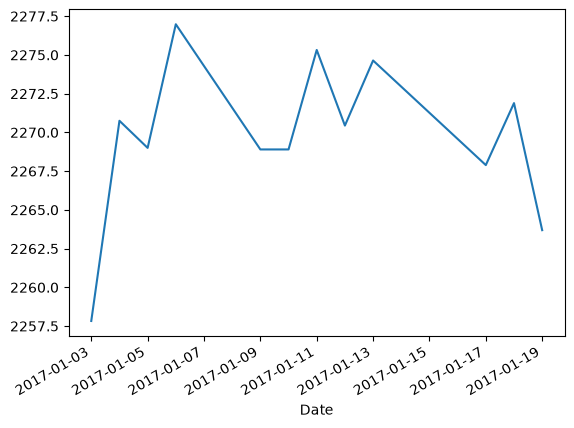

In [82]:
# slice Close prices by date range, then draw a line plot
database.loc["2017-01-01":"2017-01-19", "Close"].plot()

<Axes: xlabel='Date'>

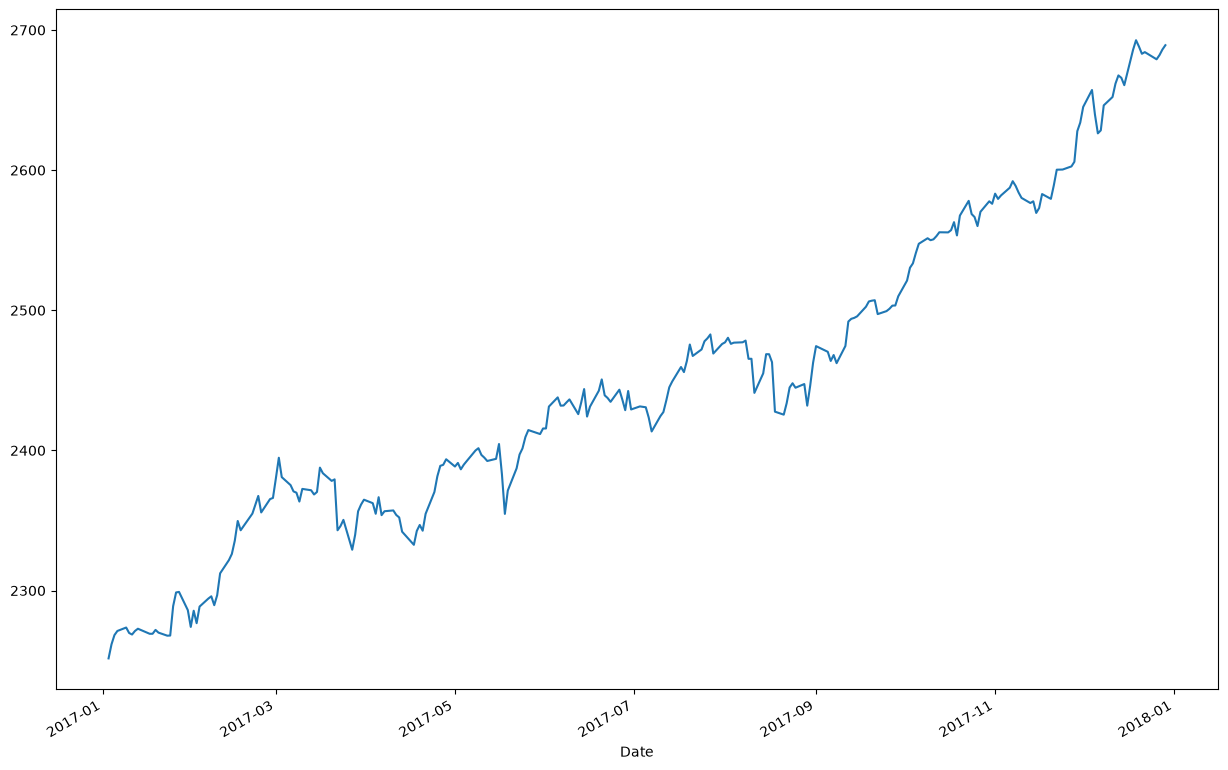

In [83]:
# Open prices over 2017-2018, figure size 15x10 inches
database.loc["2017":"2018", "Open"].plot(figsize=(15, 10))

<Axes: title={'center': 'S&P500'}, xlabel='Date'>

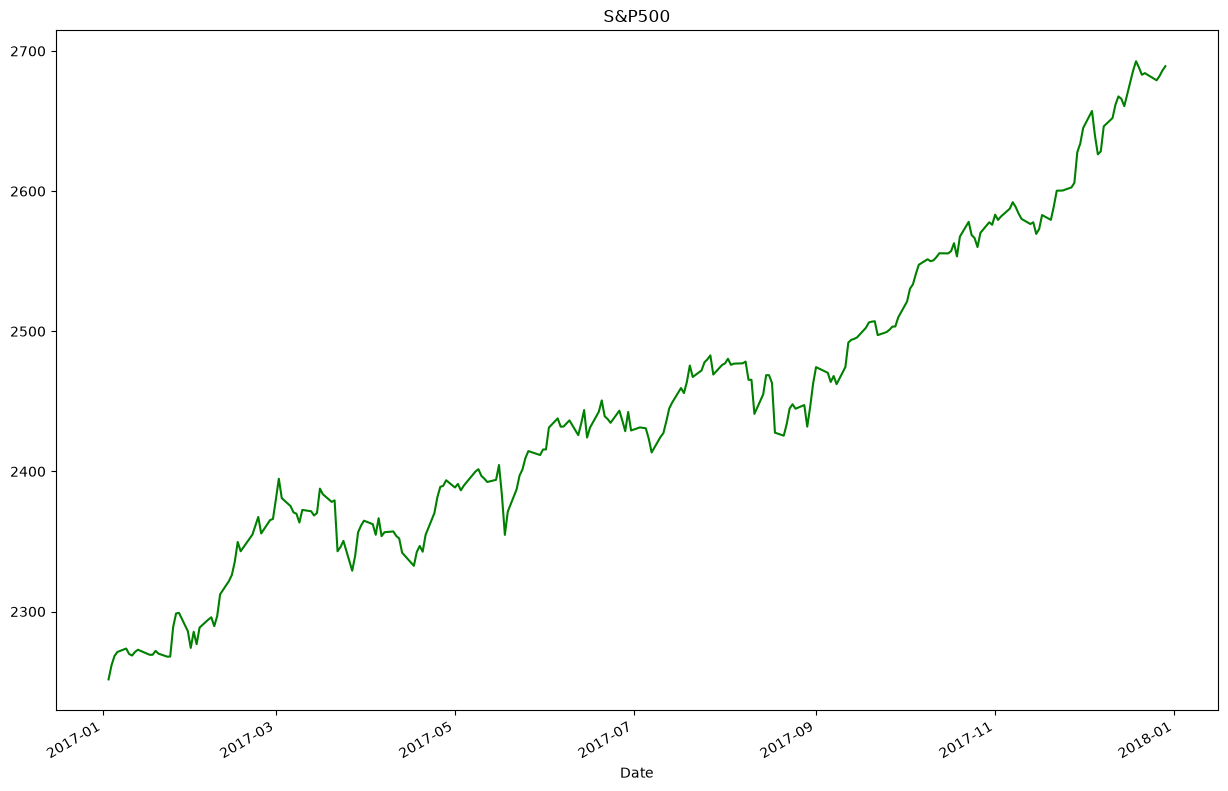

In [84]:
# same plot with a title and a green line
database.loc["2017":"2018", "Open"].plot(figsize=(15, 10), title="S&P500", color='green')

<Axes: >

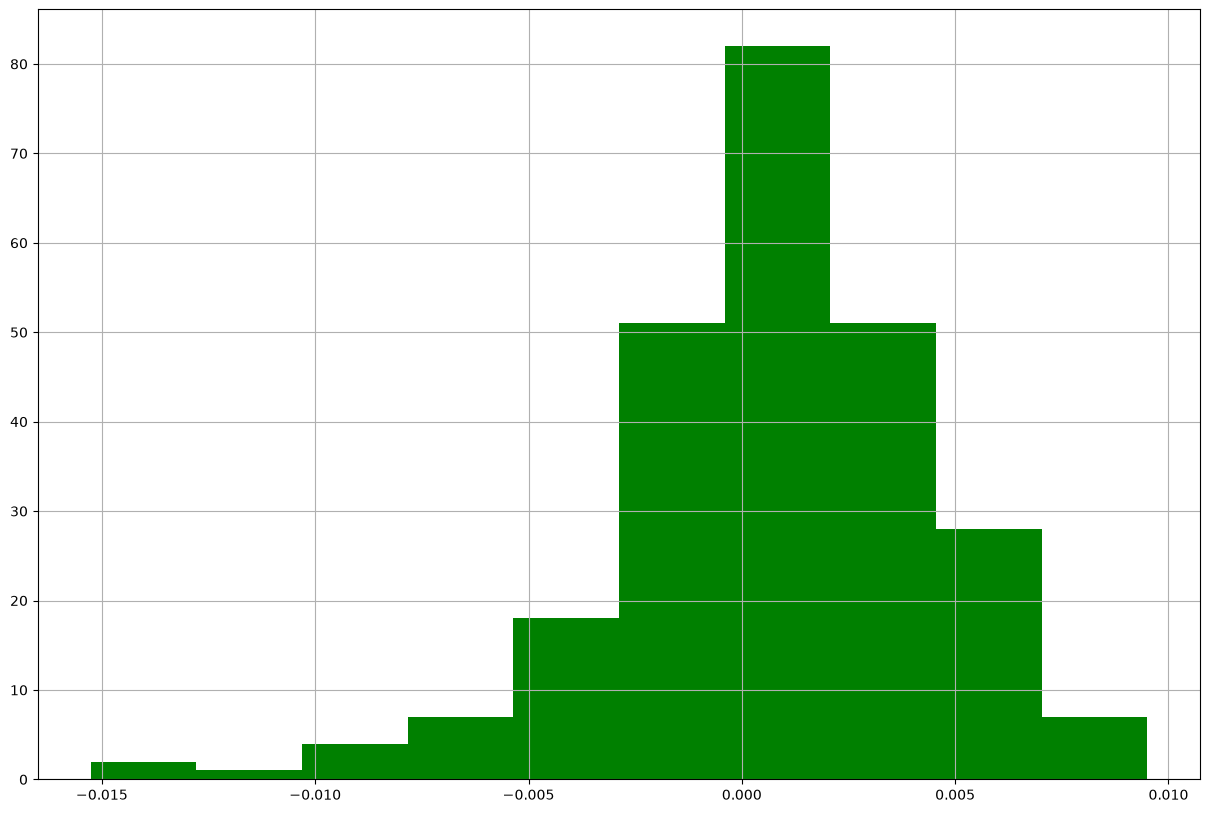

In [90]:
# histogram of daily Open returns: shows their distribution
pctdata.loc["2017":"2018", "Open"].hist(figsize=(15, 10), color='green')

In [91]:
# NumPy array of the prices (index/column labels dropped; column 0 = Open)
data = database.values

In [92]:
# NumPy array of the returns (column 0 = Open)
datapct = pctdata.values

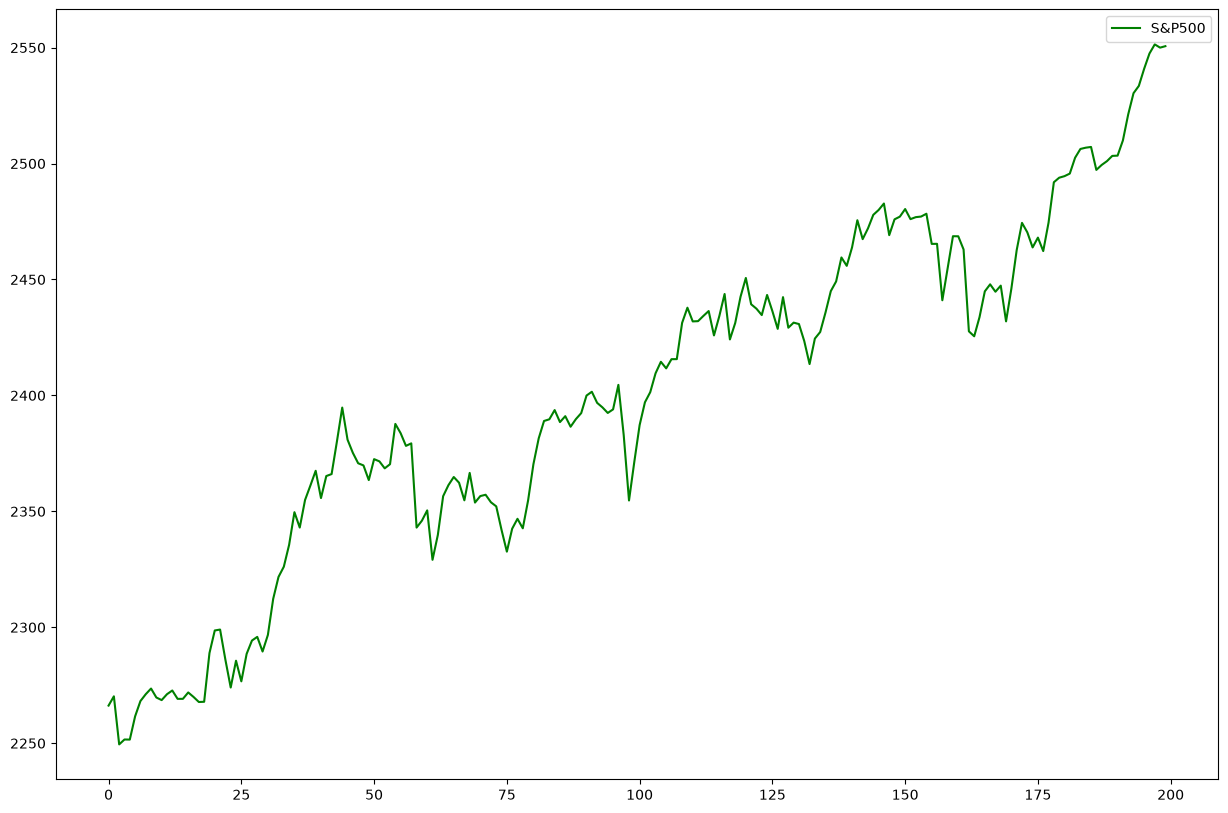

In [98]:
# create a new empty figure, 15x10 inches
plt.figure(figsize=(15, 10))
# plot rows 500-699 of column 0 (Open) from the array
plt.plot(data[500:700, 0:1], label='S&P500', color='green')

# display the legend box (uses the label= above)
plt.legend()
# render the figure
plt.show()

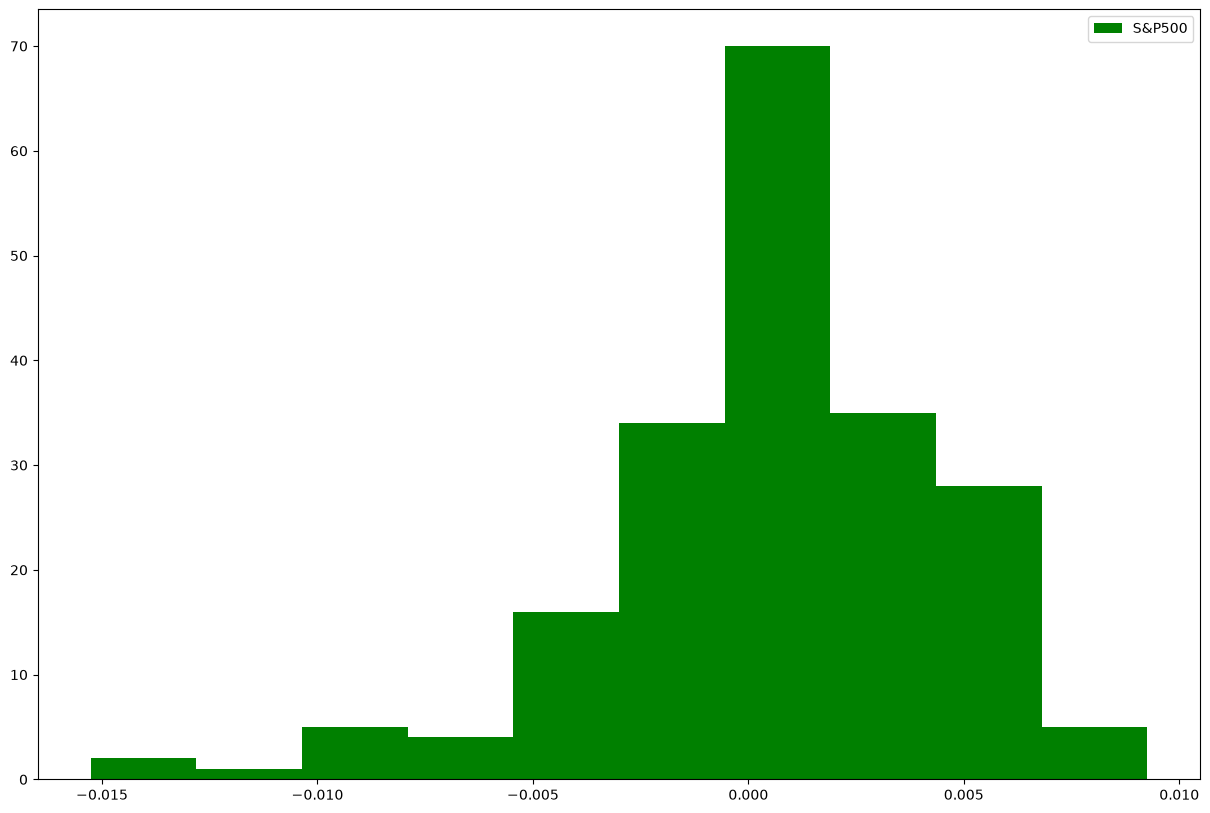

In [99]:
# create a new empty figure, 15x10 inches
plt.figure(figsize=(15, 10))
# histogram of rows 500-699 of column 0 of the returns
plt.hist(datapct[500:700, 0:1], label='S&P500', color='green')

# display the legend box
plt.legend()
# render the figure
plt.show()

In [101]:
# autocorrelation-function plot from the statsmodels package
from statsmodels.graphics.tsaplots import plot_acf

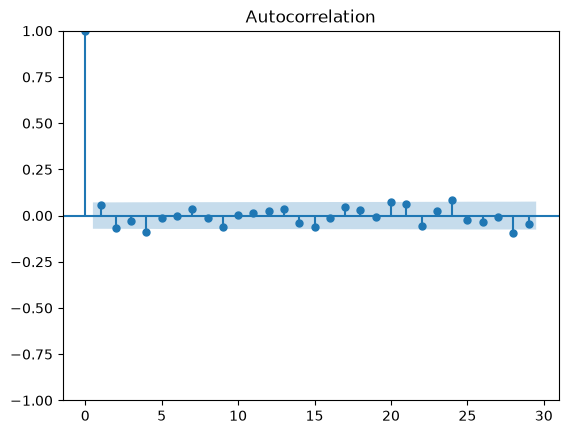

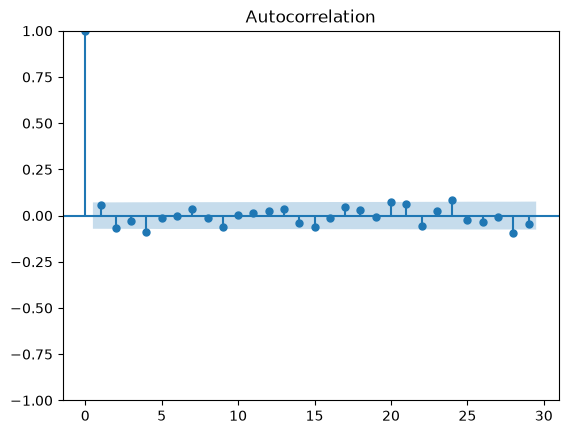

In [103]:
# correlation of daily Open returns with themselves lagged 1, 2, 3... days (bars outside the blue band are significant)
plot_acf(pctdata[['Open']])

In [119]:
# new column: mean of Open over a rolling window of 60 trading days (~3-month trend)
database['Moving_Average_60'] = database[['Open']].rolling(60).mean()

In [120]:
# new column: mean of Open over a rolling window of 190 trading days (longer trend)
database['Moving_Average_190'] = database[['Open']].rolling(190).mean()

<Axes: xlabel='Date'>

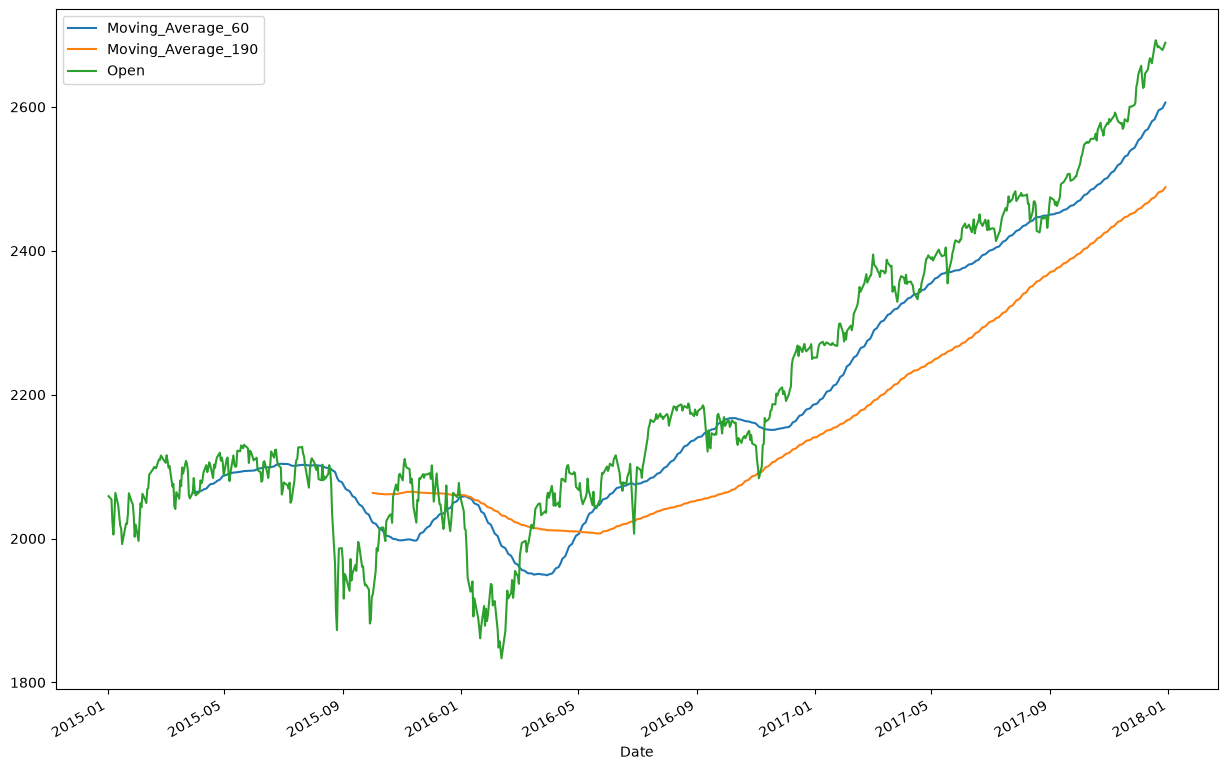

In [123]:
# plot Open against its two moving averages (one line per column)
database[['Open', 'Moving_Average_60', 'Moving_Average_190']].plot(figsize=(15, 10))